## Introduction

In this script, the shape files of Bengalore at the ward level are read in. These shape files are .kml files. Since they are difficult to work with, they are converted to .shp files using GDAL. 

We also do some basic plots and data exploration.

The source of the data is from [Opencity](https://data.opencity.in/dataset/gba-wards-delimitation-2025/resource/9013d656-8051-4e2d-9648-46efd0d86d3d).

## Importing the Python libraries

In [106]:
import subprocess
from pathlib import Path

import geopandas as gpd
import pandas as pd

## Conversion to shape files

In [85]:
parent_dir = Path.cwd().parent
parent_dir

WindowsPath('c:/Ellen/personal/projects/geospatial/lst_bang_chennai/lstroad')

In [86]:
file_path_bangalore = parent_dir / "data" / "raw"/ "gba-369-wards-december-2025.kml"

File formats such as .kml are difficult to work with. Although Geopandas can read such files using the appropriate drivers, it is very common that columns get truncated. Hence, GDAL was used from within this Python script to conver the kml files to shape files:

In [87]:
shp_file_bangalore = parent_dir / "data" / "interim"/ "bangalore.shp"

In [88]:
cmd = [
    "ogr2ogr",
    "-f", "ESRI Shapefile",         
    str(shp_file_bangalore),          
    str(file_path_bangalore)            
]

In [89]:
subprocess.run(cmd, check=True)

CompletedProcess(args=['ogr2ogr', '-f', 'ESRI Shapefile', 'c:\\Ellen\\personal\\projects\\geospatial\\lst_bang_chennai\\lstroad\\data\\interim\\bangalore.shp', 'c:\\Ellen\\personal\\projects\\geospatial\\lst_bang_chennai\\lstroad\\data\\raw\\gba-369-wards-december-2025.kml'], returncode=0)

## Exploratory analysis

In [90]:
gdf_bangalore = gpd.read_file(shp_file_bangalore)

In [91]:
print(f'There are  {gdf_bangalore.shape[0]} wards in Bangalore')
print(f'There are  {gdf_bangalore.shape[1]} columns in the dataset for Bangalore')

There are  369 wards in Bangalore
There are  40 columns in the dataset for Bangalore


<Axes: >

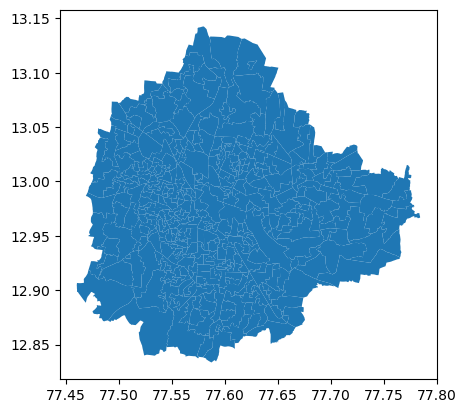

In [92]:
gdf_bangalore.plot()

In [93]:
gdf_bangalore.head()

,id,Name,descriptio,timestamp,begin,end,altitudeMo,tessellate,extrude,visibility,...,ST_F,low_range,high_range,RO_Code,RO_Divisio,ARO_Code,ARO_ Sub D,zone,zone_name,geometry
0,ward_369_final.1,None,None,None,None,None,None,-1,0,-1,...,201.0,18949,28424,11,RO- Rajarajeswari Nagara,34,ARO- Jnana Bharathi,Zone1,Rajarajeshwarinagar,"POLYGON ((77.51174 12.9554, 77.51163 12.95538,..."
1,ward_369_final.2,None,None,None,None,None,None,-1,0,-1,...,270.0,19943,29914,11,RO- Yelahanka,29,ARO- Yelahanka Old Town,Zone2,Yelahanka,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13..."
2,ward_369_final.3,None,None,None,None,None,None,-1,0,-1,...,213.0,19943,29914,11,RO- Yelahanka,29,ARO- Yelahanka Old Town,Zone2,Yelahanka,"POLYGON ((77.56668 13.11875, 77.56655 13.11755..."
3,ward_369_final.17,None,None,None,None,None,None,-1,0,-1,...,161.0,14567,21851,3,RO- Ramamurthy Nagara,8,ARO- Ramamurthy Nagara,Zone2,K.R. Pura,"POLYGON ((77.67055 13.01757, 77.67197 13.01829..."
4,ward_369_final.4,None,None,None,None,None,None,-1,0,-1,...,187.0,19943,29914,4,RO- Hebbal,11,ARO- Nagashettyhalli,Zone2,Yelahanka,"POLYGON ((77.56897 13.03653, 77.56892 13.03715..."


In [94]:
gdf_bangalore.columns

Index(['id', 'Name', 'descriptio', 'timestamp', 'begin', 'end', 'altitudeMo',
       'tessellate', 'extrude', 'visibility', 'drawOrder', 'icon',
       'Corporatio', 'corporat_1', 'corporat_2', 'ac', 'ac_kn', 'ac_no',
       'Assembly', 'ward_id', 'ward_name', 'ward_name_', 'TOT_P', 'TOT_M',
       'TOT_F', 'SC_P', 'SC_M', 'SC_F', 'ST_P', 'ST_M', 'ST_F', 'low_range',
       'high_range', 'RO_Code', 'RO_Divisio', 'ARO_Code', 'ARO_ Sub D', 'zone',
       'zone_name', 'geometry'],
      dtype='object')

In [95]:
# Set options to display all rows and columns
pd.set_option("display.max_rows", None)

In [96]:
missing_values_count = gdf_bangalore.isna().sum()
print("Missing values per column:")
print(missing_values_count)

Missing values per column:
id              0
Name          369
descriptio    369
timestamp     369
begin         369
end           369
altitudeMo    369
tessellate      0
extrude         0
visibility      0
drawOrder     369
icon          369
Corporatio      0
corporat_1      0
corporat_2      0
ac              0
ac_kn           0
ac_no           0
Assembly        0
ward_id         0
ward_name       0
ward_name_      0
TOT_P           0
TOT_M           0
TOT_F           0
SC_P            0
SC_M            0
SC_F            0
ST_P            0
ST_M            0
ST_F            0
low_range       0
high_range      0
RO_Code         0
RO_Divisio      0
ARO_Code        0
ARO_ Sub D      0
zone            0
zone_name       0
geometry        0
dtype: int64


In [97]:
gdf_bangalore['Corporatio'].value_counts()

Corporatio
West       112
North       72
South       72
Central     63
East        50
Name: count, dtype: int64

In [98]:
gdf_bangalore['zone_name'].value_counts()

zone_name
Malleshwaram           57
Rajarajeshwarinagar    55
Byatarayanapura        41
Gandhinagara           40
Bommanahalli           36
Jayanagar              36
Yelahanka              31
K.R. Pura              27
C.V. Raman Nagar       23
Mahadevapura           23
Name: count, dtype: int64

## Basic data cleaning 

Let's keep only the columns that are needed:

In [99]:
cols_to_keep = [
    "ward_id",
    "ward_name",
    "Corporatio",
    "geometry",
]

gdf_bangalore = gdf_bangalore[cols_to_keep]
gdf_bangalore.head()

,ward_id,ward_name,Corporatio,geometry
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.51174 12.9554, 77.51163 12.95538,..."
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13..."
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.56668 13.11875, 77.56655 13.11755..."
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.67055 13.01757, 77.67197 13.01829..."
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.56897 13.03653, 77.56892 13.03715..."


Next, we check if the geometries are valid. The reason for doing so is that they can cause trouble later on in the analysis. 

In [100]:
valid = gdf_bangalore.is_valid
valid.value_counts()

True     361
False      8
Name: count, dtype: int64

Initially, we tried to make the polygons valid in Geopandas itself and then ran them through a validity check in QGIS. Running the check in QGIS revealed that still one polygon was invalid. We also ran Mapshaper to check the validity on top of this. 

Hence, the validity and topology checking was done in QGIS and Mapshaper following the [YouTube tutorial of Ujaval Gandhi](https://www.youtube.com/watch?v=iyDj8AvX3H0). 

Before fixing the polygons, let's save to a shape file:

In [101]:
shp_file_bangalore_trimmed = parent_dir / "data" / "interim"/ "bangalore_trimmed.shp"

In [102]:
gdf_bangalore.to_file(shp_file_bangalore_trimmed)

## Appendix

The reason for the invalid geometries:

In [103]:
invalid = gdf_bangalore[~gdf_bangalore.is_valid]

print(len(invalid))

invalid

8


,ward_id,ward_name,Corporatio,geometry
18,20,20 - Kengeri Kote ward,West,"POLYGON ((77.47286 12.91765, 77.47298 12.91747..."
23,7,7 - Byrasandra,South,"POLYGON ((77.58956 12.92247, 77.58807 12.92249..."
41,43,43 - Bheereshwara Nagar,South,"POLYGON ((77.56993 12.8837, 77.57015 12.88429,..."
126,27,27 - Ambedkarnagar,Central,"POLYGON ((77.62352 12.9526, 77.62384 12.95254,..."
161,61,61 - Kodi Chikkanahalli,South,"POLYGON ((77.62426 12.90905, 77.62417 12.90904..."
169,24,24 - A Adugodi,South,"POLYGON ((77.60981 12.94372, 77.60886 12.94373..."
175,20,20 - Madiwala,South,"POLYGON ((77.62274 12.9173, 77.62273 12.9173, ..."
325,96,96 - Kathriguppe,West,"POLYGON ((77.55064 12.93443, 77.55067 12.93446..."


In [104]:
invalid = invalid.copy()
invalid['reason_invalid'] = invalid.geometry.is_valid_reason()
invalid

,ward_id,ward_name,Corporatio,geometry,reason_invalid
18,20,20 - Kengeri Kote ward,West,"POLYGON ((77.47286 12.91765, 77.47298 12.91747...",Self-intersection[77.4748652723178 12.88041595...
23,7,7 - Byrasandra,South,"POLYGON ((77.58956 12.92247, 77.58807 12.92249...",Ring Self-intersection[77.5796173153649 12.933...
41,43,43 - Bheereshwara Nagar,South,"POLYGON ((77.56993 12.8837, 77.57015 12.88429,...",Ring Self-intersection[77.5754586460418 12.895...
126,27,27 - Ambedkarnagar,Central,"POLYGON ((77.62352 12.9526, 77.62384 12.95254,...",Self-intersection[77.6058583875397 12.94978736...
161,61,61 - Kodi Chikkanahalli,South,"POLYGON ((77.62426 12.90905, 77.62417 12.90904...",Ring Self-intersection[77.6227287492428 12.917...
169,24,24 - A Adugodi,South,"POLYGON ((77.60981 12.94372, 77.60886 12.94373...",Self-intersection[77.6058583875397 12.94978736...
175,20,20 - Madiwala,South,"POLYGON ((77.62274 12.9173, 77.62273 12.9173, ...",Ring Self-intersection[77.6227287492428 12.917...
325,96,96 - Kathriguppe,West,"POLYGON ((77.55064 12.93443, 77.55067 12.93446...",Self-intersection[77.554463419882 12.923566001...


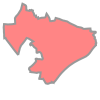

In [105]:
invalid.geometry.iloc[0]

## References

https://pythongis.org/part2/chapter-06/nb/02-geometric-operations.html

https://stackoverflow.com/questions/15637961/matplotlib-alignment-of-legend-title

Ujaval Gandhi (2023) - YouTube Tutorial on [Fix Topological and Geometry Errors using QGIS and Mapshaper](https://www.youtube.com/watch?v=iyDj8AvX3H0)